# Encoder Backbone Comparison on Low-Resource Ukrainian ASR

## Idea

This notebook builds a minimal CTC-based ASR pipeline and swaps **only the encoder block** while holding everything else constant (data, frontend, decoder, optimizer, seed). ASR is chosen not as an end goal but as a clean primitive testbed. Setup is simply audio in, characters out, CER as a single comparable metric.

The experiment also introduces a **dual-mode chunked evaluation** that isolates a property unique to stateful (recurrent/SSM) architectures (the ability to carry internal state across inference boundaries). This directly measures whether persistent memory provides a practical advantage in streaming scenarios.

## Hypotheses
1. Lightweight recurrent/SSM encoders (Mamba, RWKV) achieve CER competitive with a Transformer encoder of comparable size on 32h audio data.

2. Under chunked inference with short context windows (2–5s), stateful architectures with state carried across chunk boundaries achieve lower CER than the same architectures with state reset.

3. Stateful encoders in carry mode degrade less from full-utterance to chunked CER than the stateless Transformer, which has no mechanism to preserve cross-chunk context.

## Approach

**Architecture:** five encoder backbones (but one is broken), all ~7M parameters, 6 layers, d_model=256:

| Backbone | Complexity | Stateful | Source |
|---|---|---|---|
| Transformer | O(T²) | No | `torch.nn.TransformerEncoder` |
| Linear Attention | O(T·D²) | No | ELU+1 kernel (Katharopoulos et al.) |
| Mamba | O(T) | Yes | `mamba-ssm` library |
| RWKV-6 | O(T) | Yes | RWKV-block repository |
| RWKV-7 (broken) | O(T) | Yes | RWKV-block repository |

**Data:** ~32h Ukrainian speech from Mozilla Common Voice, character-level CTC, no external language model.

**Evaluation.**
1. standard CER/WER on complete test audio on the full utterance
2. chunked reset with each chunk (2s/5s/10s) processed independently, state zeroed at boundaries. Equal for all backbones.
3. chunked carry with state flows from chunk to chunk. Only for Mamba and RWKV. The difference (reset − carry) quantifies the value of persistent memory.

**Note:** In this run chunked modes are evaluated the different subset of test utterances, and that is what must be taken into the account in the Results section.

# Setup

In [ ]:
!pip -q uninstall -y torch torchvision torchaudio torchtext torchdata functorch triton onnx onnxruntime onnxscript torch-onnx
!pip -q cache purge

!pip uninstall -y torch torchvision torchaudio
!pip install -U pip
!pip install torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1 --index-url https://download.pytorch.org/whl/cu124

!pip uninstall -y mamba-ssm causal-conv1d
!pip install causal-conv1d mamba-ssm --no-build-isolation

!pip install -q datasets soundfile librosa jiwer torchaudio huggingface_hub

Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.1/797.1 MB 27.0 MB/s  0:00:12
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 114.5 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 103.6 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.5/209.5 MB 101.7 MB/s  0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [torchaudio]
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for causal-conv1d: filename=causal_conv1d-1.6.0-cp312-cp312-linux_x86_64.whl size=253715074 sha256=f2f6cf5f114b86674dd9c80de3e4f2a4c76e6bf9d9c1c21b35165775a8f6a43b
  Stored in directory: /root/.cache/pip/wheels/9a/1e/2e/a0c04cf5c155486922378c8a2f111ac9705a354a949dd724a4
  Created wheel for mamba-ssm: filename=mamba_ssm-2.3.0-cp312-cp312-linux_x86_64.whl size=533244411 sha256=ea759e631ed848a5d403aab5b985febfcfa445b95b158649fdda14f6b6726fe2
  Stored in 

In [ ]:
!git clone https://github.com/RWKV/RWKV-block.git

from pathlib import Path
import re

root = Path("/content/RWKV-block")

dropout_repls = [
    ("nn.Dropout(p = dropout_rate,device=device)", "nn.Dropout(p = dropout_rate)"),
    ("nn.Dropout(p=dropout_rate,device=device)",   "nn.Dropout(p=dropout_rate)"),
    ("nn.Dropout(p = dropout_rate, device=device)", "nn.Dropout(p = dropout_rate)"),
    ("nn.Dropout(p=dropout_rate, device=device)",   "nn.Dropout(p=dropout_rate)"),
]

dropout_patched = 0
for p in root.rglob("*.py"):
    txt = p.read_text(encoding="utf-8")
    new = txt
    for a, b in dropout_repls:
        new = new.replace(a, b)
    if new != txt:
        p.write_text(new, encoding="utf-8")
        dropout_patched += 1
        print("patched dropout in:", p)

print(f"Dropout patches applied to {dropout_patched} file(s).")

path = root / "rwkv_block/v7_goose/block/rwkv7_layer_block.py"
lines = path.read_text(encoding="utf-8").splitlines(True)

out = []
patched = 0
pat = re.compile(r"^(\s*)self\.([A-Za-z_][A-Za-z0-9_]*)\.reset_parameters\(\)\s*$")

for line in lines:
    m = pat.match(line.rstrip("\n"))
    if not m:
        out.append(line)
        continue

    indent, name = m.group(1), m.group(2)
    out.append(f"{indent}{name} = self._modules.get('{name}', None)\n")
    out.append(f"{indent}rp = getattr({name}, 'reset_parameters', None)\n")
    out.append(f"{indent}if callable(rp):\n")
    out.append(f"{indent}    rp()\n")
    patched += 1

path.write_text("".join(out), encoding="utf-8")
print(f"RWKV7 reset_parameters patched {patched} call(s) in {path}")

import sys
sys.path.insert(0, "/content/RWKV-block")

Cloning into 'RWKV-block'...
remote: Enumerating objects: 3162, done.
remote: Counting objects: 100% (211/211), done.
remote: Compressing objects: 100% (140/140), done.
remote: Total 3162 (delta 111), reused 136 (delta 71), pack-reused 2951 (from 1)
Receiving objects: 100% (3162/3162), 31.48 MiB | 38.42 MiB/s, done.
Resolving deltas: 100% (2040/2040), done.
patched dropout in: /content/RWKV-block/rwkv_block/v6_finch/block/rwkv6_layer_block.py
patched dropout in: /content/RWKV-block/rwkv_block/v6_gold_finch/block/gold_finch_layer_block.py
patched dropout in: /content/RWKV-block/rwkv_block/v5_eagle/block/rwkv5_layer_block.py
Dropout patches applied to 3 file(s).
RWKV7 reset_parameters patched 5 call(s) in /content/RWKV-block/rwkv_block/v7_goose/block/rwkv7_layer_block.py


# Imports

In [ ]:
import os
import re
import csv
import math
import time
import json
import random
import subprocess
import tarfile
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, Dict, List, Tuple

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas

import urllib.request, urllib.error, unicodedata

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import torchaudio
import torchaudio.transforms as T

from datasets import load_dataset, Audio
from jiwer import wer as compute_wer

from mamba_ssm import Mamba

from rwkv_block.v6_finch.block.rwkv6_layer_block import RWKV6LayerBlock
from rwkv_block.v6_finch.block.rwkv6_block_config_map import RWKV6BlockConfigMap
from rwkv_block.v7_goose.block.rwkv7_layer_block import RWKV7LayerBlock
from rwkv_block.v7_goose.block.rwkv7_block_config_map import RWKV7BlockConfigMap

[WARNING] fla not available, falling back to triton, cuda or pytorch mode - install fla from `https://github.com/fla-org/flash-linear-attention`


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


# Experiment Config

In [ ]:
@dataclass
class ExperimentConfig:
    # Data
    max_train_hours: float = 35.0 # cap training data
    max_val_hours: float = 5.0 # cap dev/validation data
    max_test_hours: float = 5.0 # cap test data
    max_audio_sec: float = 15.0 # drop utterances longer than this
    min_audio_sec: float = 0.5 # drop very short utterances
    sample_rate: int = 16000
    n_mels: int = 80
    win_length_ms: int = 25
    hop_length_ms: int = 10

    # Model
    d_model: int = 256
    n_layers: int = 6
    n_heads: int = 4 # for Transformer / linear attn
    head_size: int = 64 # for RWKV (d_model must be divisible by this)
    ffn_mult: int = 5
    dropout: float = 0.15
    conv_channels: int = 256 # front-end conv channels

    # Training
    batch_max_seconds: float = 240.0 # dynamic batching budget (total audio sec per batch)
    num_epochs: int = 30
    lr: float = 3e-4
    weight_decay: float = 0.01
    warmup_steps: int = 500
    grad_clip: float = 5.0
    seed: int = 42

    # Augmentation
    spec_augment: bool = True
    freq_mask_param: int = 15
    time_mask_param: int = 35
    num_freq_masks: int = 2
    num_time_masks: int = 2

    # Evaluation
    chunk_sizes_sec: List[float] = field(default_factory=lambda: [2.0, 5.0, 10.0])
    max_carry_eval_utterances: int = 500 # limit for slow carry-state eval

    # Paths
    output_dir: str = "./asr_experiment"
    data_dir: str = "./cv_data" # where Common Voice gets extracted

    # Mozilla Common Voice Download
    cv_api_key: str = ""
    cv_dataset_id: str = "cmj8u3pys00t5nxxb56wugqgq"
    cv_tarball_name: str = "Common Voice Scripted Speech 24.0 - Ukrainian.tar.gz"

cfg = ExperimentConfig()

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(cfg.seed)
os.makedirs(cfg.output_dir, exist_ok=True)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Dataset

## Normalization Utils

In [ ]:
UK_LETTERS = "абвгґдеєжзиіїйклмнопрстуфхцчшщьюя"
ALLOWED_RE = re.compile(rf"[^ {UK_LETTERS}']") # everything else → space

APOS_VARIANTS = ["\u2019", "\u02bc", "\u2018", "\u055a", "\u02bc"]
DASH_VARIANTS = ["—", "–", "-"]
QUOTE_VARIANTS = ["«", "»", "\u201c", "\u201d", "\u201e", "\""]

LATIN_I_RE = re.compile(r"i") # after lower()
ANY_LATIN_RE = re.compile(r"[a-z]") # after fixing latin i→ cyrillic і
LEADING_DASH_RE = re.compile(r"^\s*[—–\-]\s*")
COMBINING_ACUTE = "\u0301"


def normalize_uk_asr(s: str) -> str:
    """
    Target charset: Ukrainian letters + space + apostrophe
    Returns normalized string (may be empty)
    """
    if not isinstance(s, str):
        return ""
    s = s.strip().lower()

    # unicode normalize; remove ONLY combining acute accent (preserve ї/й)
    s = unicodedata.normalize("NFD", s)
    s = s.replace(COMBINING_ACUTE, "")
    s = unicodedata.normalize("NFC", s)

    # unify apostrophes
    for a in APOS_VARIANTS:
        s = s.replace(a, "'")

    # fix latin 'i' → cyrillic 'і'
    s = LATIN_I_RE.sub("і", s)

    # remove leading dialogue dash (— / – / -)
    s = LEADING_DASH_RE.sub("", s)

    # dashes inside text → spaces
    for d in DASH_VARIANTS:
        s = s.replace(d, " ")

    # quotes and ellipsis → spaces
    for q in QUOTE_VARIANTS:
        s = s.replace(q, " ")
    s = s.replace("…", " ")

    # drop everything non-allowed → spaces
    s = ALLOWED_RE.sub(" ", s)

    # collapse whitespace
    s = re.sub(r"\s+", " ", s).strip()
    return s


def _has_remaining_latin(raw: str) -> bool:
    """Return True if text contains latin letters after i→і substitution → should drop"""
    if not isinstance(raw, str):
        return True
    s = raw.strip().lower()
    for a in APOS_VARIANTS:
        s = s.replace(a, "'")
    s = LATIN_I_RE.sub("і", s)
    return bool(ANY_LATIN_RE.search(s))

## Vocabulary

In [ ]:
class CharVocab:
    """Character-level vocabulary built from training transcripts"""

    def __init__(self):
        self.blank = "<blank>"
        self.pad = "<pad>"
        self.space = " "
        self.char2idx: Dict[str, int] = {}
        self.idx2char: Dict[int, str] = {}

    def build(self, texts: List[str]):
        chars = set()
        for t in texts:
            chars.update(t)
        chars = sorted(chars)

        self.char2idx[self.blank] = 0
        idx = 1
        for c in chars:
            self.char2idx[c] = idx
            idx += 1

        self.char2idx[self.pad] = idx

        self.idx2char = {v: k for k, v in self.char2idx.items()}
        return self

    def encode(self, text: str) -> List[int]:
        return [self.char2idx[c] for c in text if c in self.char2idx]

    def decode(self, indices: List[int]) -> str:
        result = []
        for idx in indices:
            if idx == 0:  # blank
                continue
            c = self.idx2char.get(idx, "")
            if c not in (self.blank, self.pad):
                result.append(c)
        return "".join(result)

    @property
    def size(self):
        return len(self.char2idx)

## Loading Data

In [ ]:
def download_common_voice(cfg: ExperimentConfig):
    """Download Common Voice Ukrainian"""
    tarball_path = os.path.join(cfg.data_dir, cfg.cv_tarball_name)
    os.makedirs(cfg.data_dir, exist_ok=True)

    extracted_root = _find_extracted_root(cfg.data_dir)
    if extracted_root is not None:
        print(f"Dataset already extracted at: {extracted_root}")
        return extracted_root

    if not os.path.exists(tarball_path):
        api_key = cfg.cv_api_key or os.environ.get("CV_API_KEY", "")
        if not api_key:
            raise ValueError(
                "No API key provided. Set cfg.cv_api_key or the CV_API_KEY "
                "environment variable.\n"
                "Get your key at: https://commonvoice.mozilla.org/en/profile/settings"
            )

        print("Requesting download URL from Mozilla datacollective API...")
        req = urllib.request.Request(
            f"https://datacollective.mozillafoundation.org/api/datasets/{cfg.cv_dataset_id}/download",
            method="POST",
            headers={
                "Authorization": f"Bearer {api_key}",
                "Content-Type": "application/json",
            },
        )
        try:
            with urllib.request.urlopen(req) as resp:
                body = json.loads(resp.read().decode())
            download_url = body["downloadUrl"]
        except (urllib.error.HTTPError, KeyError) as e:
            raise RuntimeError(
                f"Failed to get download URL: {e}\n"
                "Check your API key and dataset ID."
            ) from e

        print(f"Downloading {cfg.cv_tarball_name} ...")
        subprocess.run(
            ["curl", "-L", "-o", tarball_path, download_url],
            check=True,
        )
        print(f"Downloaded to {tarball_path} ({os.path.getsize(tarball_path) / 1e9:.2f} GB)")
    else:
        print(f"Tarball already exists: {tarball_path}")

    print("Extracting tarball (this may take a few minutes)...")
    with tarfile.open(tarball_path, "r:gz") as tar:
        tar.extractall(path=cfg.data_dir)
    print("Extraction complete.")

    extracted_root = _find_extracted_root(cfg.data_dir)
    if extracted_root is None:
        raise FileNotFoundError(
            f"Could not find extracted dataset with 'clips' folder in {cfg.data_dir}. "
            "Check the tarball structure."
        )
    print(f"Dataset root: {extracted_root}")
    return extracted_root


def _find_extracted_root(data_dir: str) -> Optional[str]:
    for root, dirs, files in os.walk(data_dir):
        if "train.tsv" in files and "clips" in dirs:
            return root
    return None


def _load_clip_durations(dataset_root: str) -> Dict[str, float]:
    """Parse clip_durations.tsv (columns: clip, duration[ms]) → dict mapping clip filename to duration in seconds"""
    dur_path = os.path.join(dataset_root, "clip_durations.tsv")
    if not os.path.isfile(dur_path):
        raise FileNotFoundError(
            f"clip_durations.tsv not found at {dur_path}. "
            "Expected in the dataset root alongside train.tsv."
        )

    durations = {}
    with open(dur_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f, delimiter="\t")
        for row in reader:
            clip = row["clip"]
            dur_ms = float(row["duration[ms]"])
            durations[clip] = dur_ms / 1000.0  # → seconds
    print(f"Loaded durations for {len(durations)} clips from clip_durations.tsv")
    return durations


def _read_tsv_safe(path: str):
    """Read a TSV with temporarily raised csv field size limit"""
    old_limit = csv.field_size_limit()
    csv.field_size_limit(10 * 1024 * 1024)  # 10 MB
    try:
        with open(path, "r", encoding="utf-8") as f:
            reader = csv.DictReader(f, delimiter="\t")
            rows = list(reader)
    finally:
        csv.field_size_limit(old_limit)
    return rows


def parse_cv_tsv(
    tsv_path: str,
    clips_dir: str,
    clip_durations: Dict[str, float],
    cfg: ExperimentConfig,
) -> List[dict]:
    """
    Parse a Common Voice TSV file with normalization.
    Returns list of dicts with keys: audio_path, sentence, client_id, duration_sec, clip_filename
    Applies: text normalization, latin filter, duration filter.
    """
    rows = _read_tsv_safe(tsv_path)

    entries = []
    n_skipped_latin = 0
    n_skipped_empty = 0
    n_skipped_nofile = 0
    n_skipped_nodur = 0
    n_skipped_duration = 0

    for row in rows:
        raw_sentence = row.get("sentence", "")

        # latin filter
        if _has_remaining_latin(raw_sentence):
            n_skipped_latin += 1
            continue

        # normalize text
        sentence = normalize_uk_asr(raw_sentence)
        if not sentence:
            n_skipped_empty += 1
            continue

        # resolve audio path
        filename = row["path"]
        if not filename.endswith(".mp3"):
            filename += ".mp3"
        audio_path = os.path.join(clips_dir, filename)

        if not os.path.isfile(audio_path):
            n_skipped_nofile += 1
            continue

        # duration from clip_durations.tsv
        dur_sec = clip_durations.get(filename)
        if dur_sec is None:
            dur_sec = clip_durations.get(row["path"])
        if dur_sec is None:
            n_skipped_nodur += 1
            continue

        if dur_sec < cfg.min_audio_sec or dur_sec > cfg.max_audio_sec:
            n_skipped_duration += 1
            continue

        entries.append({
            "audio_path": audio_path,
            "sentence": sentence,
            "client_id": row.get("client_id", ""),
            "duration_sec": dur_sec,
            "clip_filename": filename,
        })

    split_name = os.path.basename(tsv_path)
    print(f"  {split_name}: {len(entries)} kept | "
          f"dropped: {n_skipped_latin} latin, {n_skipped_empty} empty, "
          f"{n_skipped_nofile} no-file, {n_skipped_nodur} no-duration, "
          f"{n_skipped_duration} out-of-range")

    return entries


def _cap_hours(entries: List[dict], max_hours: float, seed: int) -> List[dict]:
    """Cap total duration to max_hours; shuffle first, then take a prefix"""
    if max_hours <= 0 or not entries:
        return entries

    rng = random.Random(seed)
    shuffled = list(entries)
    rng.shuffle(shuffled)

    max_sec = max_hours * 3600
    cumulative = 0.0
    for i, e in enumerate(shuffled):
        cumulative += e["duration_sec"]
        if cumulative >= max_sec:
            return shuffled[: i + 1]

    return shuffled


def load_and_prepare_data(cfg: ExperimentConfig):
    """Download Common Voice Ukrainian, parse TSVs, filter, normalize, and split"""
    # download
    dataset_root = download_common_voice(cfg)
    clips_dir = os.path.join(dataset_root, "clips")

    # clip durations
    clip_durations = _load_clip_durations(dataset_root)

    # parse splits with normalization + duration filter
    train_tsv = os.path.join(dataset_root, "train.tsv")
    dev_tsv = os.path.join(dataset_root, "dev.tsv")
    test_tsv = os.path.join(dataset_root, "test.tsv")

    has_dev_split = os.path.isfile(dev_tsv)

    print("Parsing & normalizing TSV files...")
    train_entries = parse_cv_tsv(train_tsv, clips_dir, clip_durations, cfg)
    test_entries = parse_cv_tsv(test_tsv, clips_dir, clip_durations, cfg)
    dev_entries = parse_cv_tsv(dev_tsv, clips_dir, clip_durations, cfg) if has_dev_split else []

    # cap hours
    train_entries = _cap_hours(train_entries, cfg.max_train_hours, cfg.seed)
    dev_entries = _cap_hours(dev_entries, cfg.max_val_hours, cfg.seed)
    test_entries = _cap_hours(test_entries, cfg.max_test_hours, cfg.seed)

    def _stats(entries, name):
        total_h = sum(e["duration_sec"] for e in entries) / 3600
        print(f"  {name}: {len(entries)} utterances ({total_h:.1f}h)")
    _stats(train_entries, "train")
    _stats(dev_entries, "dev")
    _stats(test_entries, "test")

    # build vocabulary from normalized training text
    all_train_texts = [e["sentence"] for e in train_entries]
    vocab = CharVocab().build(all_train_texts)
    print(f"Vocabulary size: {vocab.size} (incl. blank + pad)")
    print(f"  chars: {''.join(sorted(c for c in vocab.char2idx if c not in (vocab.blank, vocab.pad)))}")

    print(f"Final — train: {len(train_entries)}, dev: {len(dev_entries)}, test: {len(test_entries)}")
    return train_entries, dev_entries, test_entries, vocab

## DataLoader

In [ ]:
class ASRDataset(Dataset):
    """Loads audio from local MP3 files, resamples to target sample rate, and produces log-mel spectrograms + character targets"""

    def __init__(self, entries: List[dict], vocab: CharVocab, cfg: ExperimentConfig):
        self.entries = entries
        self.vocab = vocab
        self.cfg = cfg

        win_samples = int(cfg.win_length_ms * cfg.sample_rate / 1000)
        hop_samples = int(cfg.hop_length_ms * cfg.sample_rate / 1000)

        self.mel_transform = T.MelSpectrogram(
            sample_rate=cfg.sample_rate,
            n_fft=max(512, win_samples),
            win_length=win_samples,
            hop_length=hop_samples,
            n_mels=cfg.n_mels,
            power=2.0,
        )

        self._resamplers: Dict[int, T.Resample] = {}

    def _get_resampler(self, orig_sr: int) -> T.Resample:
        if orig_sr not in self._resamplers:
            self._resamplers[orig_sr] = T.Resample(orig_sr, self.cfg.sample_rate)
        return self._resamplers[orig_sr]

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        entry = self.entries[idx]

        waveform, sr = torchaudio.load(entry["audio_path"])

        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        waveform = waveform.squeeze(0)

        if sr != self.cfg.sample_rate:
            waveform = self._get_resampler(sr)(waveform)

        mel = self.mel_transform(waveform) # (n_mels, T)
        mel = torch.clamp(mel, min=1e-9).log() # log-mel

        mel = (mel - mel.mean()) / (mel.std() + 1e-8) # per-utterance mean-var normalization

        targets = torch.tensor(self.vocab.encode(entry["sentence"]), dtype=torch.long) # encode text

        return mel, targets


def collate_fn(batch):
    """Pad mel spectrograms and targets to form a batch"""
    mels, targets = zip(*batch)

    # mels: (B, n_mels, T_max)
    mel_lengths = [m.shape[1] for m in mels]
    max_mel_len = max(mel_lengths)
    padded_mels = torch.zeros(len(mels), mels[0].shape[0], max_mel_len)
    for i, m in enumerate(mels):
        padded_mels[i, :, :m.shape[1]] = m

    # targets: (B, L_max)
    target_lengths = [t.shape[0] for t in targets]
    max_target_len = max(target_lengths)
    padded_targets = torch.zeros(len(targets), max_target_len, dtype=torch.long)
    for i, t in enumerate(targets):
        padded_targets[i, :t.shape[0]] = t

    mel_lengths = torch.tensor(mel_lengths, dtype=torch.long)
    target_lengths = torch.tensor(target_lengths, dtype=torch.long)

    return padded_mels, padded_targets, mel_lengths, target_lengths


class DurationBatchSampler:
    """Dynamic batching with at most `max_seconds` total audio per batch"""
    def __init__(self, entries: List[dict], max_seconds: float,
                 shuffle: bool = True, seed: int = 42):
        self.durations = [e["duration_sec"] for e in entries]
        self.max_seconds = max_seconds
        self.shuffle = shuffle
        self.seed = seed
        self.epoch = 0

    def __iter__(self):
        indices = list(range(len(self.durations)))
        if self.shuffle:
            rng = random.Random(self.seed + self.epoch)
            rng.shuffle(indices)

        batch = []
        batch_dur = 0.0
        for idx in indices:
            d = self.durations[idx]
            if batch_dur + d > self.max_seconds and batch:
                yield batch
                batch = [idx]
                batch_dur = d
            else:
                batch.append(idx)
                batch_dur += d

        if batch:
            yield batch

        self.epoch += 1

    def __len__(self):
        total_dur = sum(self.durations)
        return max(1, int(total_dur / self.max_seconds))

## Augumentation

In [ ]:
class SpecAugment(nn.Module):
    def __init__(self, freq_mask_param, time_mask_param, n_freq_masks, n_time_masks):
        super().__init__()
        self.freq_masks = nn.ModuleList([
            T.FrequencyMasking(freq_mask_param) for _ in range(n_freq_masks)
        ])
        self.time_masks = nn.ModuleList([
            T.TimeMasking(time_mask_param) for _ in range(n_time_masks)
        ])

    def forward(self, x):
        """x: (B, n_mels, T)"""
        for fm in self.freq_masks:
            x = fm(x)
        for tm in self.time_masks:
            x = tm(x)
        return x

# Model Components

## Shared

In [ ]:
class ConvSubsampling(nn.Module):
    """Two conv layers with stride 2 in time → 4x downsampling"""

    def __init__(self, n_mels, d_model, channels=256):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, channels, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )
        # after 2x stride twice freq_dim = ceil(n_mels/4)
        freq_out = math.ceil(n_mels / 2)
        freq_out = math.ceil(freq_out / 2)
        self.proj = nn.Linear(channels * freq_out, d_model)
        self.d_model = d_model

    def forward(self, x, lengths):
        """
        x: (B, n_mels, T)
        lengths: (B,) original mel lengths
        Returns: (B, T', d_model), new_lengths
        """
        x = x.unsqueeze(1) # (B, 1, n_mels, T)
        x = self.conv(x) # (B, C, n_mels/4, T/4)
        B, C, F, T = x.shape
        x = x.permute(0, 3, 1, 2).reshape(B, T, C * F) # (B, T', C*F)
        x = self.proj(x)# (B, T', d_model)

        # Compute new lengths after 4x subsampling
        new_lengths = ((lengths - 1) // 2 + 1)
        new_lengths = ((new_lengths - 1) // 2 + 1)
        new_lengths = torch.clamp(new_lengths, min=1)

        return x, new_lengths

class CTCHead(nn.Module):
    def __init__(self, d_model, vocab_size):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.proj = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        return self.proj(self.norm(x))

## Backbones

### Small Transformer Encoder

In [ ]:
class TransformerEncoder(nn.Module):
    supports_carry_state = False # stateless: full attention recomputed per chunk

    def __init__(self, d_model, n_heads, n_layers, ffn_dim, dropout):
        super().__init__()
        self.pos_enc = SinusoidalPE(d_model, max_len=8000)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ffn_dim,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)

    def forward(self, x, lengths, state=None):
        """x: (B, T, D), lengths: (B,); stateless"""
        x = self.pos_enc(x)
        B, T, _ = x.shape
        mask = torch.arange(T, device=x.device).unsqueeze(0) >= lengths.unsqueeze(1)
        x = self.encoder(x, src_key_padding_mask=mask)
        return x, None  # no state to carry


class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=8000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x, offset=0):
        """offset: position offset for carry-state PE continuity"""
        x = x + self.pe[:, offset : offset + x.size(1)]
        return self.dropout(x)

### Linear Attention Encoder

In [ ]:
class LinearAttentionLayer(nn.Module):
    """
    Linear attention with ELU+1 feature map (Katharopoulos et al., 2020).
    O(T*D^2) instead of O(T^2*D).
    Bidirectional within each chunk; no recurrent state to carry.
    """
    def __init__(self, d_model, n_heads, ffn_dim, dropout):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.o_proj = nn.Linear(d_model, d_model)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model),
            nn.Dropout(dropout),
        )
        self.dropout = nn.Dropout(dropout)

    @staticmethod
    def elu_feature_map(x):
        return F.elu(x) + 1.0

    def forward(self, x, mask=None):
        B, T, D = x.shape
        residual = x
        x = self.norm1(x)

        Q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        K = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        V = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        Q = self.elu_feature_map(Q)
        K = self.elu_feature_map(K)

        if mask is not None:
            m = (~mask).float().unsqueeze(1).unsqueeze(-1)
            K = K * m
            V = V * m

        KV = torch.einsum("bhnd,bhne->bhde", K, V)
        Z = 1.0 / (torch.einsum("bhnd,bhd->bhn", Q, K.sum(dim=2)) + 1e-6)
        out = torch.einsum("bhnd,bhde,bhn->bhne", Q, KV, Z)

        out = out.transpose(1, 2).reshape(B, T, D)
        out = self.dropout(self.o_proj(out))
        x = residual + out
        x = x + self.ffn(self.norm2(x))
        return x


class LinearAttentionEncoder(nn.Module):
    # bidirectional within chunk
    # causal carry-state would require a different training regime
    # marked unsupported to keep comparison fair
    supports_carry_state = False

    def __init__(self, d_model, n_heads, n_layers, ffn_dim, dropout):
        super().__init__()
        self.pos_enc = SinusoidalPE(d_model, max_len=8000)
        self.layers = nn.ModuleList([
            LinearAttentionLayer(d_model, n_heads, ffn_dim, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, lengths, state=None):
        x = self.pos_enc(x)
        B, T, _ = x.shape
        mask = torch.arange(T, device=x.device).unsqueeze(0) >= lengths.unsqueeze(1)
        for layer in self.layers:
            x = layer(x, mask=mask)
        return x, None # no state

### Mamba Encoder

In [ ]:
# class MambaEncoder(nn.Module):
#     """
#     Uses Mamba SSM blocks as sequence mixer.
#     Supports carry-state for chunked streaming inference via step().
#     """
#     supports_carry_state = True

#     def __init__(self, d_model, n_layers, dropout):
#         super().__init__()
#         self.d_model = d_model
#         self.n_layers = n_layers

#         self.layers = nn.ModuleList()
#         for _ in range(n_layers):
#             self.layers.append(nn.ModuleDict({
#                 "norm1": nn.LayerNorm(d_model),
#                 "mamba": Mamba(d_model=d_model, d_state=16, d_conv=4, expand=2),
#                 "norm2": nn.LayerNorm(d_model),
#                 "ffn": nn.Sequential(
#                     nn.Linear(d_model, d_model * 4),
#                     nn.GELU(),
#                     nn.Dropout(dropout),
#                     nn.Linear(d_model * 4, d_model),
#                     nn.Dropout(dropout),
#                 ),
#             }))

#         # cache Mamba inner dims for state allocation
#         self._d_inner = self.layers[0]["mamba"].d_inner
#         self._d_state = self.layers[0]["mamba"].d_state
#         self._d_conv = self.layers[0]["mamba"].d_conv
#         self.dropout = nn.Dropout(dropout)
#         print("Mamba encoder initialized"
#               f"({n_layers} layers, d_model={d_model}, d_inner={self._d_inner}, d_state=16, d_conv=4, expand=2)")

#     def forward(self, x, lengths, state=None):
#         if state is not None:
#             return self._forward_carry(x, state)
#         return self._forward_stateless(x)

#     def _forward_stateless(self, x):
#         """Fast fused forward (training + reset-state eval)"""
#         for layer in self.layers:
#             residual = x
#             x = residual + self.dropout(layer["mamba"](layer["norm1"](x)))
#             x = x + layer["ffn"](layer["norm2"](x))
#         return x, None

#     def _forward_carry(self, x, state):
#         """Carry-state via mamba.step() token-by-token, slow but correct"""
#         B, T, D = x.shape
#         new_state = []
#         for layer_idx, layer in enumerate(self.layers):
#             conv_st, ssm_st = state[layer_idx]
#             residual = x
#             x_norm = layer["norm1"](x)
#             outputs = []
#             for t in range(T):
#                 out_t, conv_st, ssm_st = layer["mamba"].step(
#                     x_norm[:, t:t+1, :], conv_st, ssm_st
#                 )
#                 outputs.append(out_t)
#             x = residual + self.dropout(torch.stack(outputs, dim=1))
#             x = x + layer["ffn"](layer["norm2"](x))
#             new_state.append((conv_st, ssm_st))
#         return x, new_state

#     def init_state(self, batch_size: int, device: torch.device):
#         # return [
#         #     (
#         #         torch.zeros(batch_size, self._d_inner, self._d_conv, device=device),
#         #         torch.zeros(batch_size, self._d_inner, self._d_state, device=device),
#         #     )
#         #     for _ in range(self.n_layers)
#         # ]
#         return [
#             layer["mamba"].allocate_inference_cache(batch_size, max_seqlen=1)
#             for layer in self.layers
#         ]

In [ ]:
def _mamba_step_pytorch(mamba_block, hidden_states, conv_state, ssm_state):
    """
    Pure-PyTorch single-token Mamba step — replaces mamba_block.step() to
    bypass the causal_conv1d CUDA kernel which has version-compatibility issues.

    Args:
        mamba_block: a mamba_ssm.Mamba module
        hidden_states: (B, 1, D)
        conv_state: (B, d_inner, d_conv)
        ssm_state: (B, d_inner, d_state)
    Returns:
        output: (B, D)
        conv_state: updated
        ssm_state: updated
    """
    import torch.nn.functional as Flocal

    dtype = hidden_states.dtype
    x_in = hidden_states.squeeze(1)  # (B, D)

    # 1. Input projection → x, z
    xz = mamba_block.in_proj(x_in)  # (B, 2*d_inner)
    x, z = xz.chunk(2, dim=-1)      # each (B, d_inner)

    # 2. Conv1d update — pure PyTorch: shift state, apply conv
    # conv_state: (B, d_inner, d_conv) — a sliding window of past inputs
    conv_state = torch.roll(conv_state, shifts=-1, dims=-1)
    conv_state[:, :, -1] = x.to(conv_state.dtype)
    # Apply depthwise conv: weight is (d_inner, 1, d_conv)
    x = (conv_state * mamba_block.conv1d.weight.squeeze(1)).sum(dim=-1)  # (B, d_inner)
    if mamba_block.conv1d.bias is not None:
        x = x + mamba_block.conv1d.bias
    x = Flocal.silu(x).to(dtype=dtype)

    # 3. SSM parameters
    x_db = mamba_block.x_proj(x)  # (B, dt_rank + 2*d_state)
    dt, B_ssm, C_ssm = torch.split(
        x_db, [mamba_block.dt_rank, mamba_block.d_state, mamba_block.d_state], dim=-1
    )
    dt = mamba_block.dt_proj(dt)  # (B, d_inner)

    # Discretize: dt → A_bar, dB
    dt = Flocal.softplus(dt)  # (B, d_inner)
    A = -mamba_block.A_log.float().exp()  # (d_inner, d_state), always negative
    dA = torch.exp(dt.unsqueeze(-1) * A.unsqueeze(0))  # (B, d_inner, d_state)
    dB = dt.unsqueeze(-1) * B_ssm.unsqueeze(1).float()  # (B, d_inner, d_state)

    # 4. SSM state update
    ssm_state = ssm_state * dA + dB * x.unsqueeze(-1).float()

    # 5. Readout
    y = (ssm_state * C_ssm.unsqueeze(1).float()).sum(dim=-1)  # (B, d_inner)
    y = y.to(dtype=dtype)

    # Add D skip connection
    y = y + mamba_block.D.float() * x

    # Gate with z
    y = y * Flocal.silu(z)

    # 6. Output projection
    out = mamba_block.out_proj(y)  # (B, D)

    return out, conv_state, ssm_state

class MambaEncoder(nn.Module):
    """
    Uses Mamba SSM blocks as sequence mixer.
    Supports carry-state for chunked streaming inference via step() API.
    Requires: pip install mamba-ssm causal-conv1d
    """
    supports_carry_state = True

    def __init__(self, d_model, n_layers, dropout):
        super().__init__()
        self.d_model = d_model
        self.n_layers = n_layers

        from mamba_ssm import Mamba  # hard dependency — no fallback

        self.layers = nn.ModuleList()
        for _ in range(n_layers):
            self.layers.append(nn.ModuleDict({
                "norm1": nn.LayerNorm(d_model),
                "mamba": Mamba(d_model=d_model, d_state=16, d_conv=4, expand=2),
                "norm2": nn.LayerNorm(d_model),
                "ffn": nn.Sequential(
                    nn.Linear(d_model, d_model * 4),
                    nn.GELU(),
                    nn.Dropout(dropout),
                    nn.Linear(d_model * 4, d_model),
                    nn.Dropout(dropout),
                ),
            }))
        self.dropout = nn.Dropout(dropout)
        print("Mamba encoder initialized"
              f"({n_layers} layers, d_model={d_model}, d_state=16, d_conv=4, expand=2)")

    def forward(self, x, lengths, state=None):
        if state is not None:
            return self._forward_carry(x, state)
        return self._forward_stateless(x)

    def _forward_stateless(self, x):
        """Fast fused forward (training + reset-state eval)."""
        for layer in self.layers:
            residual = x
            x = residual + self.dropout(layer["mamba"](layer["norm1"](x)))
            x = x + layer["ffn"](layer["norm2"](x))
        return x, None

    def _forward_carry(self, x, state):
        """Carry-state via token-by-token stepping in pure PyTorch."""
        B, T, D = x.shape
        new_state = []
        for layer_idx, layer in enumerate(self.layers):
            conv_st, ssm_st = state[layer_idx]
            residual = x
            x_norm = layer["norm1"](x)
            outputs = []
            for t in range(T):
                out_t, conv_st, ssm_st = _mamba_step_pytorch(
                    layer["mamba"], x_norm[:, t:t+1, :], conv_st, ssm_st
                )
                outputs.append(out_t)
            x = residual + self.dropout(torch.stack(outputs, dim=1))
            x = x + layer["ffn"](layer["norm2"](x))
            new_state.append((conv_st, ssm_st))
        return x, new_state

    def init_state(self, batch_size: int, device: torch.device):
        """Allocate zero state matching each Mamba block's weight dtypes."""
        states = []
        for layer in self.layers:
            mb = layer["mamba"]
            conv_dtype = mb.conv1d.weight.dtype
            states.append((
                torch.zeros(batch_size, mb.d_inner, mb.d_conv,
                            dtype=conv_dtype, device=device),
                torch.zeros(batch_size, mb.d_inner, mb.d_state,
                            dtype=torch.float32, device=device),
            ))
        return states

### RWKV-6 Encoder

In [ ]:
class RWKV6Encoder(nn.Module):
    """
    RWKV v6 (Finch) blocks as a sequence encoder.

    d_model must be divisible by 32 (RWKV internal requirement).
    WKV state is always kept in float32 regardless of weight dtype.
    """
    supports_carry_state = True

    def __init__(self, d_model, n_layers, dropout, head_size=64,
                 dtype=torch.float32, tmix_backend="auto"):
        super().__init__()
        assert d_model % 32 == 0, f"d_model must be divisible by 32, got {d_model}"
        assert d_model % head_size == 0, (
            f"d_model ({d_model}) must be divisible by head_size ({head_size})"
        )

        self.d_model = d_model
        self.n_layers = n_layers
        self.n_head = d_model // head_size
        self.head_size = head_size

        self.layers = nn.ModuleList()
        for i in range(n_layers):
            cfg = RWKV6BlockConfigMap(
                num_hidden_layers=n_layers,
                hidden_size=d_model,
                head_size=head_size,
                dropout_rate=dropout,
                layer_id=i,
                tmix_backend=tmix_backend,
                dtype=dtype,
            )
            self.layers.append(RWKV6LayerBlock(cfg))

        print(f"RWKV-6 encoder initialized "
              f"({n_layers} layers, d_model={d_model}, head_size={head_size})")

    def forward(self, x, lengths=None, state=None):
        if state is not None:
            return self._forward_carry(x, state)
        return self._forward_stateless(x)

    def _forward_stateless(self, x):
        state = self.init_state(x.shape[0], x.device)
        for i, layer in enumerate(self.layers):
            x, state[i] = layer(x, state[i])
        return x, None

    def _forward_carry(self, x, state):
        new_state = []
        for i, layer in enumerate(self.layers):
            x, new_layer_state = layer(x, state[i])
            new_state.append(new_layer_state)
        return x, new_state

    def init_state(self, batch_size, device):
        """Per-layer state: (tmix_shift, wkv, cmix_shift)."""
        return [
            (
                torch.zeros(batch_size, self.d_model, device=device),
                torch.zeros(batch_size, self.n_head, self.head_size, self.head_size,
                            dtype=torch.float32, device=device),
                torch.zeros(batch_size, self.d_model, device=device),
            )
            for _ in range(self.n_layers)
        ]

### RWKV-7 Encoder

In [ ]:
class RWKV7Encoder(nn.Module):
    """
    RWKV v7 (Goose) blocks as a sequence encoder.

    Passes a value-residual tensor from layer 0 to all
    deeper layers. Its shape is [B, T, d_model], tied to chunk length, so it
    resets each forward call and is NOT part of carry-state.
    """
    supports_carry_state = True

    def __init__(self, d_model, n_layers, dropout, head_size=64,
                 dtype=torch.float32, tmix_backend="auto"):
        super().__init__()
        assert d_model % 32 == 0, f"d_model must be divisible by 32, got {d_model}"
        assert d_model % head_size == 0, (
            f"d_model ({d_model}) must be divisible by head_size ({head_size})"
        )

        self.d_model = d_model
        self.n_layers = n_layers
        self.n_head = d_model // head_size
        self.head_size = head_size

        self.layers = nn.ModuleList()
        for i in range(n_layers):
            cfg = RWKV7BlockConfigMap(
                num_hidden_layers=n_layers,
                hidden_size=d_model,
                head_size=head_size,
                dropout_rate=dropout,
                layer_id=i,
                tmix_backend=tmix_backend,
                dtype=dtype,
            )
            block = RWKV7LayerBlock(cfg)
            block.reset_parameters()
            self.layers.append(block)

        print(f"RWKV-7 encoder initialized "
              f"({n_layers} layers, d_model={d_model}, head_size={head_size})")

    def forward(self, x, lengths=None, state=None):
        # those layer forward methods use with torch.device(device)
        # which sets the default tensor creation device to CUDA for the duration of that block
        # when control returns to the DataLoader's sampler (which runs in the main process between batches),
        # torch.randperm inherits the leaked CUDA default
        # but the sampler's random generator is CPU, causing the mismatch
        prev_default = torch.get_default_device() # fix: save default cpu
        try:
            if state is not None:
                return self._forward_carry(x, state)
            return self._forward_stateless(x)
        finally:
            torch.set_default_device(prev_default) # fix: restore cpu

    def _forward_stateless(self, x):
        state = self.init_state(x.shape[0], x.device)
        v_first = None
        for i, layer in enumerate(self.layers):
            x, state[i], v_first = layer(x, state[i], v_first)
        return x, None

    def _forward_carry(self, x, state):
        new_state = []
        v_first = None # resets per chunk (seq-length-dependent, not recurrent)
        for i, layer in enumerate(self.layers):
            x, new_layer_state, v_first = layer(x, state[i], v_first)
            new_state.append(new_layer_state)
        return x, new_state

    def init_state(self, batch_size, device):
        """Per-layer state: (tmix_shift, wkv, cmix_shift); same layout as v6."""
        return [
            (
                torch.zeros(batch_size, self.d_model, device=device),
                torch.zeros(batch_size, self.n_head, self.head_size, self.head_size,
                            dtype=torch.float32, device=device),
                torch.zeros(batch_size, self.d_model, device=device),
            )
            for _ in range(self.n_layers)
        ]

## Model

In [ ]:
class ASRModel(nn.Module):
    def __init__(self, backbone_type: str, vocab_size: int, cfg: ExperimentConfig):
        super().__init__()
        self.backbone_type = backbone_type

        self.frontend = ConvSubsampling(cfg.n_mels, cfg.d_model, cfg.conv_channels)

        ffn_dim = cfg.d_model * cfg.ffn_mult
        if backbone_type == "transformer":
            self.encoder = TransformerEncoder(
                cfg.d_model, cfg.n_heads, cfg.n_layers, ffn_dim, cfg.dropout
            )
        elif backbone_type == "linear_attention":
            self.encoder = LinearAttentionEncoder(
                cfg.d_model, cfg.n_heads, cfg.n_layers, ffn_dim, cfg.dropout
            )
        elif backbone_type == "mamba":
            self.encoder = MambaEncoder(cfg.d_model, cfg.n_layers, cfg.dropout)
        elif backbone_type == "rwkv6":
            self.encoder = RWKV6Encoder(
                cfg.d_model, cfg.n_layers, cfg.dropout, head_size=cfg.head_size,
            )
        elif backbone_type == "rwkv7":
            self.encoder = RWKV7Encoder(
                cfg.d_model, cfg.n_layers, cfg.dropout, head_size=cfg.head_size,
            )
        else:
            raise ValueError(f"Unknown backbone: {backbone_type}")

        self.ctc_head = CTCHead(cfg.d_model, vocab_size)

    @property
    def supports_carry_state(self):
        return self.encoder.supports_carry_state

    def forward(self, mels, mel_lengths, state=None):
        """
        mels: (B, n_mels, T)
        mel_lengths: (B,)
        state: encoder carry-state (None for stateless / reset mode)
        Returns: log_probs (B, T', vocab), output_lengths (B,), new_state
        """
        x, lengths = self.frontend(mels, mel_lengths)
        x, new_state = self.encoder(x, lengths, state=state)
        logits = self.ctc_head(x)
        log_probs = F.log_softmax(logits, dim=-1)
        return log_probs, lengths, new_state

### Number of Parameters Check

In [ ]:
# backbones = ["transformer", "linear_attention", "mamba", "rwkv6", "rwkv7"]
# _, _, _, vocab = load_and_prepare_data(cfg)

# for bb in backbones:
#     model = ASRModel(bb, vocab.size, cfg).to(device)
#     n_params = count_parameters(model)
#     print(f"Parameters for {bb}: {n_params:,} ({n_params/1e6:.2f}M)")

# CTC Decoding

In [ ]:
def greedy_ctc_decode(log_probs, lengths, vocab: CharVocab):
    """
    Greedy CTC decoding: argmax -> collapse repeats -> remove blanks.
    log_probs: (B, T, V)
    Returns: list of decoded strings
    """
    predictions = log_probs.argmax(dim=-1) # (B, T)
    decoded = []
    for i in range(predictions.size(0)):
        seq = predictions[i, :lengths[i]].tolist()
        # collapse repeats
        collapsed = []
        prev = -1
        for s in seq:
            if s != prev:
                collapsed.append(s)
            prev = s
        # remove blanks (idx 0)
        collapsed = [c for c in collapsed if c != 0]
        decoded.append(vocab.decode(collapsed))
    return decoded


def compute_cer(hypotheses: List[str], references: List[str]) -> float:
    total_chars = 0
    total_errors = 0
    for hyp, ref in zip(hypotheses, references):
        ref_chars = list(ref)
        hyp_chars = list(hyp)
        if len(ref_chars) == 0:
            total_errors += len(hyp_chars)
            continue

        r = " ".join(ref_chars) if ref_chars else " "
        h = " ".join(hyp_chars) if hyp_chars else " "
        total_chars += len(ref_chars)
        total_errors += compute_wer(r, h) * len(ref_chars)
    return total_errors / max(total_chars, 1)

# Training Loop

In [ ]:
def train_one_epoch(model, dataloader, optimizer, scheduler, spec_aug, cfg, epoch):
    model.train()
    ctc_loss_fn = nn.CTCLoss(blank=0, reduction="mean", zero_infinity=True)

    total_loss = 0.0
    n_batches = 0

    for batch_idx, (mels, targets, mel_lengths, target_lengths) in enumerate(dataloader):
        mels = mels.to(device)
        targets = targets.to(device)
        mel_lengths = mel_lengths.to(device)
        target_lengths = target_lengths.to(device)

        if spec_aug is not None:
            mels = spec_aug(mels)

        # forward
        log_probs, output_lengths, _ = model(mels, mel_lengths)

        # CTC loss expects (T, B, V)
        log_probs_ctc = log_probs.permute(1, 0, 2)

        # clamp output lengths to not exceed actual output time dimension
        output_lengths = torch.clamp(output_lengths, max=log_probs.size(1))

        loss = ctc_loss_fn(log_probs_ctc, targets, output_lengths, target_lengths)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  !!! Skipping batch {batch_idx} (loss={loss.item():.4f})")
            continue

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        n_batches += 1

        if batch_idx % 50 == 0:
            print(f"  Epoch {epoch} | Batch {batch_idx} | Loss: {loss.item():.4f} | "
                  f"LR: {scheduler.get_last_lr()[0]:.2e}")

    avg_loss = total_loss / max(n_batches, 1)
    return avg_loss


@torch.no_grad()
def evaluate(model, dataloader, vocab: CharVocab, tag="dev"):
    model.eval()
    all_hyps = []
    all_refs = []
    ctc_loss_fn = nn.CTCLoss(blank=0, reduction="mean", zero_infinity=True)
    total_loss = 0.0
    n_batches = 0

    for mels, targets, mel_lengths, target_lengths in dataloader:
        mels = mels.to(device)
        targets = targets.to(device)
        mel_lengths = mel_lengths.to(device)
        target_lengths = target_lengths.to(device)

        log_probs, output_lengths, _ = model(mels, mel_lengths)
        output_lengths = torch.clamp(output_lengths, max=log_probs.size(1))

        loss = ctc_loss_fn(
            log_probs.permute(1, 0, 2), targets, output_lengths, target_lengths
        )
        total_loss += loss.item()
        n_batches += 1

        hyps = greedy_ctc_decode(log_probs.cpu(), output_lengths.cpu(), vocab)
        for i in range(targets.size(0)):
            ref = vocab.decode(targets[i, :target_lengths[i]].tolist())
            all_refs.append(ref)
        all_hyps.extend(hyps)

    cer = compute_cer(all_hyps, all_refs)

    wer_val = compute_wer(
        [" ".join(r.split()) if r.strip() else "⟨empty⟩" for r in all_refs],
        [" ".join(h.split()) if h.strip() else "⟨empty⟩" for h in all_hyps],
    )
    avg_loss = total_loss / max(n_batches, 1)

    print(f"  [{tag}] Loss: {avg_loss:.4f} | CER: {cer:.4f} | WER: {wer_val:.4f}")

    for i in range(min(3, len(all_hyps))):
        print(f"    REF: {all_refs[i][:80]}")
        print(f"    HYP: {all_hyps[i][:80]}")
        print()

    return {"loss": avg_loss, "cer": cer, "wer": wer_val}

# Chunked Inference

In [ ]:
@torch.no_grad()
def evaluate_chunked(model, dataset, vocab, chunk_sec, cfg, carry_state=False):
    """
    Evaluate with forced chunking.

    Two modes:
      carry_state=False (reset): each chunk processed independently, encoder
          state reset at every boundary. Tests "limited context only".
      carry_state=True (carry): encoder internal state is passed from chunk
          to chunk. Tests whether persistent memory improves over reset.
          Only meaningful for recurrent/SSM backbones (Mamba, RWKV-6).

    CTC decoding: greedy argmax per chunk, global collapse across the
    concatenated token sequence to avoid boundary artifacts.
    """
    model.eval()
    hop_samples = int(cfg.hop_length_ms * cfg.sample_rate / 1000)
    chunk_frames = int(chunk_sec * cfg.sample_rate / hop_samples)

    can_carry = carry_state and model.supports_carry_state
    if carry_state and not model.supports_carry_state:
        return None # carry-state not supported for this backbone

    # limit evaluation set for slow carry-state (step-by-step Mamba)
    n_eval = len(dataset)
    if can_carry and cfg.max_carry_eval_utterances > 0:
        n_eval = min(n_eval, cfg.max_carry_eval_utterances)

    all_hyps = []
    all_refs = []

    for idx in range(n_eval):
        mel, targets = dataset[idx] # mel: (n_mels, T), targets: (L,)
        T_total = mel.shape[1]

        enc_state = None
        if can_carry:
            enc_state = model.encoder.init_state(batch_size=1, device=device)

        chunk_hyp_tokens = []
        prev_token_across_chunks = -1

        for start in range(0, T_total, chunk_frames):
            end = min(start + chunk_frames, T_total)
            chunk_mel = mel[:, start:end].unsqueeze(0).to(device)  # (1, n_mels, T_chunk)
            chunk_len = torch.tensor([chunk_mel.shape[2]], dtype=torch.long).to(device)

            # forward
            log_probs, out_lens, new_state = model(
                chunk_mel, chunk_len, state=enc_state
            )
            out_lens = torch.clamp(out_lens, max=log_probs.size(1))

            if can_carry:
                enc_state = new_state # carry state to next chunk

            # freedy decode this chunk
            preds = log_probs.argmax(dim=-1)[0, :out_lens[0]].tolist()

            # collapse repeats within chunk
            collapsed = []
            prev = -1
            for p in preds:
                if p != prev:
                    collapsed.append(p)
                prev = p

            # cross-chunk boundary dedup (skip if same non-blank token)
            if collapsed and collapsed[0] == prev_token_across_chunks and collapsed[0] != 0:
                collapsed = collapsed[1:]

            if collapsed:
                prev_token_across_chunks = collapsed[-1]

            chunk_hyp_tokens.extend(collapsed)

        # remove blanks from full sequence
        final_tokens = [t for t in chunk_hyp_tokens if t != 0]
        hyp = vocab.decode(final_tokens)
        ref = vocab.decode(targets.tolist())

        all_hyps.append(hyp)
        all_refs.append(ref)

    cer = compute_cer(all_hyps, all_refs)
    wer_val = compute_wer(
        [" ".join(r.split()) if r.strip() else "⟨empty⟩" for r in all_refs],
        [" ".join(h.split()) if h.strip() else "⟨empty⟩" for h in all_hyps],
    )
    return {"cer": cer, "wer": wer_val, "n_evaluated": n_eval}

# Experiment

In [ ]:
def run_experiment(backbone_type: str, train_entries, dev_entries, test_entries,
                   vocab: CharVocab, cfg: ExperimentConfig):
    """Train and evaluate a single backbone."""

    print(f"\n{'='*35}")
    print(f"  BACKBONE: {backbone_type.upper()}")
    print(f"{'='*35}\n")

    # datasets
    train_dataset = ASRDataset(train_entries, vocab, cfg)
    dev_dataset = ASRDataset(dev_entries, vocab, cfg)
    test_dataset = ASRDataset(test_entries, vocab, cfg)

    # dataloaders
    train_loader = DataLoader(
        train_dataset, batch_size=32, shuffle=True,
        collate_fn=collate_fn, num_workers=2, pin_memory=True, drop_last=True,
    )
    dev_loader = DataLoader(
        dev_dataset, batch_size=32, shuffle=False,
        collate_fn=collate_fn, num_workers=2, pin_memory=True,
    )
    test_loader = DataLoader(
        test_dataset, batch_size=32, shuffle=False,
        collate_fn=collate_fn, num_workers=2, pin_memory=True,
    )

    # model
    model = ASRModel(backbone_type, vocab.size, cfg).to(device)
    n_params = count_parameters(model)
    print(f"Parameters: {n_params:,} ({n_params/1e6:.2f}M)")

    # optimizer/scheduler
    total_steps = len(train_loader) * cfg.num_epochs
    optimizer = AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=1e-6)

    warmup_scheduler = WarmupScheduler(optimizer, scheduler, cfg.warmup_steps)

    # augument
    spec_aug = SpecAugment(
        cfg.freq_mask_param, cfg.time_mask_param,
        cfg.num_freq_masks, cfg.num_time_masks,
    ) if cfg.spec_augment else None

    # training
    best_dev_cer = float("inf")
    best_epoch = 0
    patience = 10
    no_improve = 0

    # per-epoch history
    history = {
        "epoch": [],
        "train_loss": [],
        "dev_loss": [],
        "dev_cer": [],
        "dev_wer": [],
        "lr": [],
        "epoch_time_s": [],
    }

    for epoch in range(1, cfg.num_epochs + 1):
        t0 = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, warmup_scheduler,
                                     spec_aug, cfg, epoch)
        dev_metrics = evaluate(model, dev_loader, vocab, tag="dev")
        elapsed = time.time() - t0

        # history
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["dev_loss"].append(dev_metrics["loss"])
        history["dev_cer"].append(dev_metrics["cer"])
        history["dev_wer"].append(dev_metrics["wer"])
        history["lr"].append(warmup_scheduler.get_last_lr()[0])
        history["epoch_time_s"].append(elapsed)

        print(f"Epoch {epoch}/{cfg.num_epochs} | Train loss: {train_loss:.4f} | "
              f"Dev CER: {dev_metrics['cer']:.4f} | Dev loss: {dev_metrics['loss']:.4f} | "
              f"Time: {elapsed:.0f}s")

        if dev_metrics["cer"] < best_dev_cer:
            best_dev_cer = dev_metrics["cer"]
            best_epoch = epoch
            no_improve = 0
            # save best model
            save_path = os.path.join(cfg.output_dir, f"best_{backbone_type}.pt")
            torch.save(model.state_dict(), save_path)
            print(f"  New best! Saved to {save_path}")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch} (best was epoch {best_epoch})")
                break

    # load best model for final eval
    model.load_state_dict(torch.load(
        os.path.join(cfg.output_dir, f"best_{backbone_type}.pt"),
        weights_only=True
    ))

    # full-utterance
    print(f"\n--- Final Test Evaluation ({backbone_type}) ---")
    test_metrics = evaluate(model, test_loader, vocab, tag="test")

    # chunked reset-state
    print(f"\n--- Chunked Inference: RESET-STATE ({backbone_type}) ---")
    chunked_reset = {}
    for chunk_sec in cfg.chunk_sizes_sec:
        print(f"  Chunk {chunk_sec}s (reset) ...")
        metrics = evaluate_chunked(model, test_dataset, vocab, chunk_sec, cfg,
                                   carry_state=False)
        chunked_reset[f"{chunk_sec}s"] = metrics
        print(f"    CER: {metrics['cer']:.4f} | WER: {metrics['wer']:.4f}")

    # chunked carry-state
    chunked_carry = {}
    if model.supports_carry_state:
        print(f"\n--- Chunked Inference: CARRY-STATE ({backbone_type}) ---")
        for chunk_sec in cfg.chunk_sizes_sec:
            print(f"  Chunk {chunk_sec}s (carry) ...")
            metrics = evaluate_chunked(model, test_dataset, vocab, chunk_sec, cfg,
                                       carry_state=True)
            if metrics is not None:
                chunked_carry[f"{chunk_sec}s"] = metrics
                print(f"    CER: {metrics['cer']:.4f} | WER: {metrics['wer']:.4f} "
                      f"(n={metrics['n_evaluated']})")
            else:
                print(f"    (carry-state not supported)")
    else:
        print(f"\n  Carry-state: N/A for {backbone_type} (stateless architecture)")

    return {
        "backbone": backbone_type,
        "n_params": n_params,
        "best_epoch": best_epoch,
        "best_dev_cer": best_dev_cer,
        "test": test_metrics,
        "chunked_reset": chunked_reset,
        "chunked_carry": chunked_carry,
        "history": history,
    }


class WarmupScheduler:
    """Linear warmup wrapper around any scheduler."""
    def __init__(self, optimizer, scheduler, warmup_steps):
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.warmup_steps = warmup_steps
        self.step_count = 0
        self.base_lrs = [pg["lr"] for pg in optimizer.param_groups]

    def step(self):
        self.step_count += 1
        if self.step_count <= self.warmup_steps:
            scale = self.step_count / self.warmup_steps
            for pg, base_lr in zip(self.optimizer.param_groups, self.base_lrs):
                pg["lr"] = base_lr * scale
        else:
            self.scheduler.step()

    def get_last_lr(self):
        return [pg["lr"] for pg in self.optimizer.param_groups]

# Plots

In [ ]:
BACKBONE_STYLE = {
    "transformer": ("Transformer", "#1f77b4", "-", "o"),
    "linear_attention": ("Linear Attention",   "#ff7f0e", "-", "s"),
    "mamba": ("Mamba", "#2ca02c", "-", "^"),
    "rwkv6": ("RWKV-6","#d62728", "-", "D"),
    "rwkv7": ("RWKV-7", "#9467bd", "-", "v"),
}


def _style(bb):
    return BACKBONE_STYLE.get(bb, (bb, "grey", "-", "x"))

def _plot_convergence(all_results, backbones, plot_dir, show=False):
    """
    Fig 1: Training convergence — 3-panel figure.
      (a) Train loss vs epoch
      (b) Dev loss vs epoch
      (c) Dev CER vs epoch
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    metrics = [
        ("train_loss", "Train Loss (CTC)", axes[0]),
        ("dev_loss",   "Dev Loss (CTC)",   axes[1]),
        ("dev_cer",    "Dev CER",          axes[2]),
    ]

    for key, ylabel, ax in metrics:
        for bb in backbones:
            h = all_results[bb]["history"]
            label, color, ls, marker = _style(bb)
            epochs = h["epoch"]
            values = h[key]

            n = len(epochs)
            mark_every = max(1, n // 10)

            ax.plot(epochs, values, color=color, linestyle=ls, linewidth=1.8,
                    marker=marker, markersize=5, markevery=mark_every,
                    label=label, alpha=0.9)

        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if key == "dev_cer":
            ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(backbones),
               fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.02))

    fig.suptitle("Training Convergence", fontsize=13, fontweight="bold", y=1.02)
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.18)

    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(plot_dir, f"convergence.{ext}"),
                    dpi=200, bbox_inches="tight")
    if show:
        return fig
    plt.close(fig)
    print("  convergence.pdf / .png")


def _plot_chunked_cer_bars(all_results, backbones, cfg, plot_dir, show=False):
    """
    Fig 2: Grouped bar chart — Test CER at full utterance + each chunk size (reset mode).
    Each backbone is a group; bars are Full / 2s / 5s / 10s.
    """
    conditions = ["Full"] + [f"{cs}s" for cs in cfg.chunk_sizes_sec]
    n_cond = len(conditions)
    n_bb = len(backbones)

    bar_width = 0.8 / n_cond
    fig, ax = plt.subplots(figsize=(max(8, n_bb * 2.2), 5))

    for j, cond in enumerate(conditions):
        cers = []
        for bb in backbones:
            r = all_results[bb]
            if cond == "Full":
                cers.append(r["test"]["cer"])
            else:
                cers.append(r["chunked_reset"][cond]["cer"])

        x = np.arange(n_bb) + j * bar_width
        bars = ax.bar(x, [c * 100 for c in cers], bar_width * 0.9,
                       label=cond, alpha=0.85)

        # Value labels on bars
        for bar, cer in zip(bars, cers):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                    f"{cer*100:.1f}", ha="center", va="bottom", fontsize=7.5)

    ax.set_xticks(np.arange(n_bb) + bar_width * (n_cond - 1) / 2)
    ax.set_xticklabels([_style(bb)[0] for bb in backbones], fontsize=10)
    ax.set_ylabel("CER (%)")
    ax.set_title("Test CER: Full Utterance vs Chunked Inference (Reset-State)",
                 fontsize=12, fontweight="bold")
    ax.legend(title="Context", fontsize=9, title_fontsize=9)
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(plot_dir, f"chunked_cer_reset.{ext}"),
                    dpi=200, bbox_inches="tight")
    if show:
        return fig
    plt.close(fig)
    print("  chunked_cer_reset.pdf / .png")


def _plot_carry_vs_reset(all_results, backbones, cfg, plot_dir, show=False):
    """
    Fig 3: Reset vs Carry CER comparison for stateful backbones.
    Side-by-side bars per chunk size, only for backbones with carry-state.
    """
    carry_bbs = [bb for bb in backbones if all_results[bb]["chunked_carry"]]
    if not carry_bbs:
        print("  carry_vs_reset: no stateful backbones, skipping")
        return

    chunk_labels = [f"{cs}s" for cs in cfg.chunk_sizes_sec]
    n_chunks = len(chunk_labels)
    n_bb = len(carry_bbs)

    fig, axes = plt.subplots(1, n_bb, figsize=(5 * n_bb, 5), squeeze=False)

    for idx, bb in enumerate(carry_bbs):
        ax = axes[0, idx]
        r = all_results[bb]
        label, color, _, _ = _style(bb)

        reset_cers = [r["chunked_reset"][cl]["cer"] * 100 for cl in chunk_labels]
        carry_cers = [r["chunked_carry"][cl]["cer"] * 100 for cl in chunk_labels
                      if cl in r["chunked_carry"]]

        x = np.arange(len(carry_cers))
        w = 0.35
        bars_r = ax.bar(x - w/2, reset_cers[:len(carry_cers)], w,
                        label="Reset", color=color, alpha=0.5)
        bars_c = ax.bar(x + w/2, carry_cers, w,
                        label="Carry", color=color, alpha=0.9)

        # Value labels
        for bars in [bars_r, bars_c]:
            for bar in bars:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                        f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)

        # Delta annotation
        for i in range(len(carry_cers)):
            delta = reset_cers[i] - carry_cers[i]
            if abs(delta) > 0.01:
                y_pos = max(reset_cers[i], carry_cers[i]) + 1.5
                sign = "−" if delta > 0 else "+"
                ax.text(x[i], y_pos, f"{sign}{abs(delta):.1f}pp",
                        ha="center", fontsize=8, fontweight="bold",
                        color="green" if delta > 0 else "red")

        ax.set_xticks(x)
        ax.set_xticklabels(chunk_labels[:len(carry_cers)])
        ax.set_ylabel("CER (%)")
        ax.set_title(label, fontsize=12, fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(axis="y", alpha=0.3, linewidth=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle("Carry-State vs Reset-State Chunked CER",
                 fontsize=13, fontweight="bold", y=1.02)
    fig.tight_layout()

    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(plot_dir, f"carry_vs_reset.{ext}"),
                    dpi=200, bbox_inches="tight")
    if show:
        return fig
    plt.close(fig)
    print("  carry_vs_reset.pdf / .png")


def plot_all(all_results: dict, backbones: list, cfg: ExperimentConfig, show: bool = False):
    """Generate all experiment plots and save to output_dir."""
    plot_dir = os.path.join(cfg.output_dir, "plots")
    os.makedirs(plot_dir, exist_ok=True)

    figs = []
    figs.append(_plot_convergence(all_results, backbones, plot_dir, show=show))
    figs.append(_plot_chunked_cer_bars(all_results, backbones, cfg, plot_dir, show=show))
    figs.append(_plot_carry_vs_reset(all_results, backbones, cfg, plot_dir, show=show))

    print(f"\nAll plots saved to {plot_dir}/")

    if show:
        preview, axs = plt.subplots(1, 3, figsize=(18, 5))
        titles = ["Training Convergence", "Chunked CER (Reset-State)", "Carry vs Reset CER"]

        for ax, fig, title in zip(axs, figs, titles):
            if fig is None:
                ax.axis("off")
                ax.set_title(title)
                continue

            canvas = FigureCanvas(fig)
            canvas.draw()
            w, h = fig.canvas.get_width_height()
            img = np.frombuffer(canvas.tostring_rgb(), dtype=np.uint8).reshape(h, w, 3)

            ax.imshow(img)
            ax.axis("off")
            ax.set_title(title, fontsize=12, fontweight="bold")

        plt.tight_layout()
        plt.show()

        for fig in figs:
            if fig is not None:
                plt.close(fig)

# Run

In [ ]:
train_ds, dev_ds, test_ds, vocab = load_and_prepare_data(cfg)

vocab_path = os.path.join(cfg.output_dir, "vocab.json")
with open(vocab_path, "w") as f:
    json.dump(vocab.char2idx, f, ensure_ascii=False, indent=2)
print(f"Vocab saved to {vocab_path}")

backbones = ["transformer", "linear_attention", "mamba", "rwkv6", "rwkv7"]
all_results = {}

for bb in backbones:
    set_seed(cfg.seed)
    results = run_experiment(bb, train_ds, dev_ds, test_ds, vocab, cfg)
    all_results[bb] = results

print("\n\n" + "-" * 25)
print("  RESULTS SUMMARY")
print("-" * 25)

print("\n  Table 1: Full utterance + Reset-state chunked CER")
header = f"{'Backbone':<20} {'Params':>8} {'DevCER':>8} {'TestCER':>8}"
for cs in cfg.chunk_sizes_sec:
    header += f" {'R@'+str(cs)+'s':>8}"
print(header)
print("-" * len(header))

for bb in backbones:
    r = all_results[bb]
    row = (f"{bb:<20} {r['n_params']/1e6:>7.2f}M "
            f"{r['best_dev_cer']:>8.4f} {r['test']['cer']:>8.4f}")
    for cs in cfg.chunk_sizes_sec:
        key = f"{cs}s"
        row += f" {r['chunked_reset'][key]['cer']:>8.4f}"
    print(row)

has_carry = any(all_results[bb]["chunked_carry"] for bb in backbones)
if has_carry:
    print(f"\n  Table 2: Carry-state chunked CER (recurrent/SSM backbones)")
    header2 = f"{'Backbone':<20} {'TestCER':>8}"
    for cs in cfg.chunk_sizes_sec:
        header2 += f" {'C@'+str(cs)+'s':>8}"
    print(header2)
    print("-" * len(header2))

    for bb in backbones:
        r = all_results[bb]
        if not r["chunked_carry"]:
            row = f"{bb:<20} {r['test']['cer']:>8.4f}  (stateless — no carry)"
        else:
            row = f"{bb:<20} {r['test']['cer']:>8.4f}"
            for cs in cfg.chunk_sizes_sec:
                key = f"{cs}s"
                if key in r["chunked_carry"]:
                    row += f" {r['chunked_carry'][key]['cer']:>8.4f}"
                else:
                    row += f" {'N/A':>8}"
        print(row)

    print(f"\n  Table 3: CER improvement from carry-state (Reset − Carry)")
    header3 = f"{'Backbone':<20}"
    for cs in cfg.chunk_sizes_sec:
        header3 += f" {'Δ@'+str(cs)+'s':>8}"
    print(header3)
    print("-" * len(header3))

    for bb in backbones:
        r = all_results[bb]
        if not r["chunked_carry"]:
            print(f"{bb:<20}  N/A (stateless)")
            continue
        row = f"{bb:<20}"
        for cs in cfg.chunk_sizes_sec:
            key = f"{cs}s"
            if key in r["chunked_carry"] and key in r["chunked_reset"]:
                delta = r["chunked_reset"][key]["cer"] - r["chunked_carry"][key]["cer"]
                sign = "+" if delta > 0 else ""
                row += f" {sign}{delta:>7.4f}"
            else:
                row += f" {'N/A':>8}"
        print(row)

results_path = os.path.join(cfg.output_dir, "results.json")
serializable = {}
for bb, r in all_results.items():
    entry = {
        "n_params": r["n_params"],
        "best_epoch": r["best_epoch"],
        "best_dev_cer": float(r["best_dev_cer"]),
        "test_cer": float(r["test"]["cer"]),
        "test_wer": float(r["test"]["wer"]),
        "test_loss": float(r["test"]["loss"]),
        "chunked_reset": {
            k: {mk: float(mv) if isinstance(mv, float) else mv
                for mk, mv in v.items()}
            for k, v in r["chunked_reset"].items()
        },
        "chunked_carry": {
            k: {mk: float(mv) if isinstance(mv, float) else mv
                for mk, mv in v.items()}
            for k, v in r["chunked_carry"].items()
        },
        "supports_carry_state": bool(r["chunked_carry"]),
        "history": {k: [float(v) if isinstance(v, float) else v
                        for v in vals]
                    for k, vals in r["history"].items()},
    }
    serializable[bb] = entry
with open(results_path, "w") as f:
    json.dump(serializable, f, indent=2)
print(f"\nResults saved to {results_path}")

plot_all(all_results, backbones, cfg)

Dataset already extracted at: ./cv_data/cv-corpus-24.0-2025-12-05/uk
Loaded durations for 90144 clips from clip_durations.tsv
Parsing & normalizing TSV files...
  train.tsv: 27002 kept | dropped: 6 latin, 0 empty, 0 no-file, 0 no-duration, 0 out-of-range
  test.tsv: 10152 kept | dropped: 6 latin, 0 empty, 0 no-file, 0 no-duration, 0 out-of-range
  dev.tsv: 9815 kept | dropped: 5 latin, 0 empty, 0 no-file, 0 no-duration, 0 out-of-range
  train: 27002 utterances (32.0h)
  dev: 3805 utterances (5.0h)
  test: 3636 utterances (5.0h)
Vocabulary size: 37 (incl. blank + pad)
  chars:  'абвгдежзийклмнопрстуфхцчшщьюяєіїґ
Final — train: 27002, dev: 3805, test: 3636
Vocab saved to ./asr_experiment/vocab.json

  BACKBONE: TRANSFORMER

Parameters: 7,440,165 (7.44M)
  Epoch 1 | Batch 0 | Loss: 8.1041 | LR: 6.00e-07
  Epoch 1 | Batch 50 | Loss: 3.2646 | LR: 3.06e-05
  Epoch 1 | Batch 100 | Loss: 3.2160 | LR: 6.06e-05
  Epoch 1 | Batch 150 | Loss: 3.2276 | LR: 9.06e-05
  Epoch 1 | Batch 200 | Loss: 3.2

# Results

Done hastily by parsing cell output instead of properly saved results, because at the end of the evaluation of the latest model, Google Notebook refused to work and disconnected runtime...

| Backbone         | Test Loss | Test CER | Test WER | Chunk 2s (reset) CER / WER | Chunk 5s (reset) CER / WER | Chunk 10s (reset) CER / WER | Chunk 2s (carry) CER / WER | Chunk 5s (carry) CER / WER | Chunk 10s (carry) CER / WER |
| ---------------- | --------: | -------: | -------: | -------------------------: | -------------------------: | --------------------------: | -------------------------: | -------------------------: | --------------------------: |
| Transformer      |    0.7612 |   0.1990 |   0.7646 |            0.2416 / 0.8297 |            0.2056 / 0.7717 |             0.1990 / 0.7643 |                        N/A |                        N/A |                         N/A |
| Linear Attention |    1.1527 |   0.3055 |   0.9344 |            0.3392 / 0.9541 |            0.3093 / 0.9367 |             0.3056 / 0.9348 |                        N/A |                        N/A |                         N/A |
| Mamba            |    1.0115 |   0.2178 |   0.7875 |            0.2702 / 0.8522 |            0.2279 / 0.7995 |             0.2178 / 0.7875 |            0.2224 / 0.7935 |            0.2208 / 0.7950 |             0.2198 / 0.7950 |
| RWKV6            |    1.0313 |   0.2592 |   0.8416 |            0.3084 / 0.8933 |            0.2674 / 0.8491 |             0.2592 / 0.8417 |            0.2644 / 0.8558 |            0.2594 / 0.8502 |             0.2588 / 0.8508 |


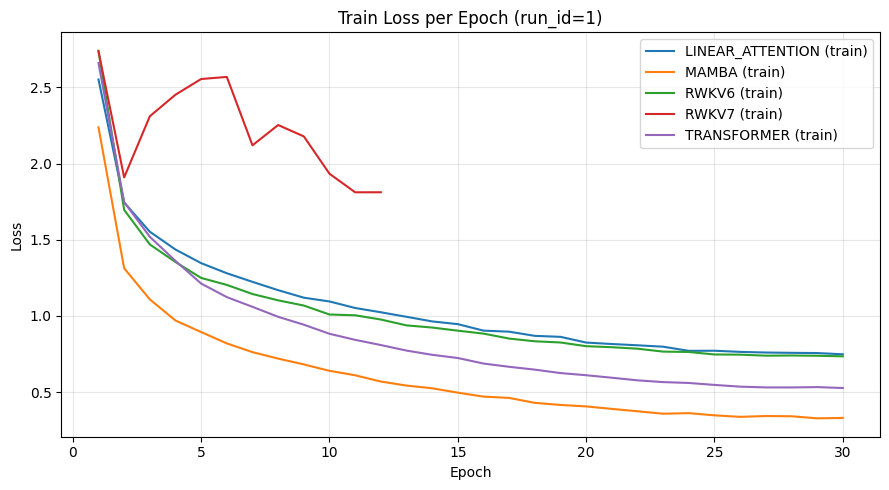

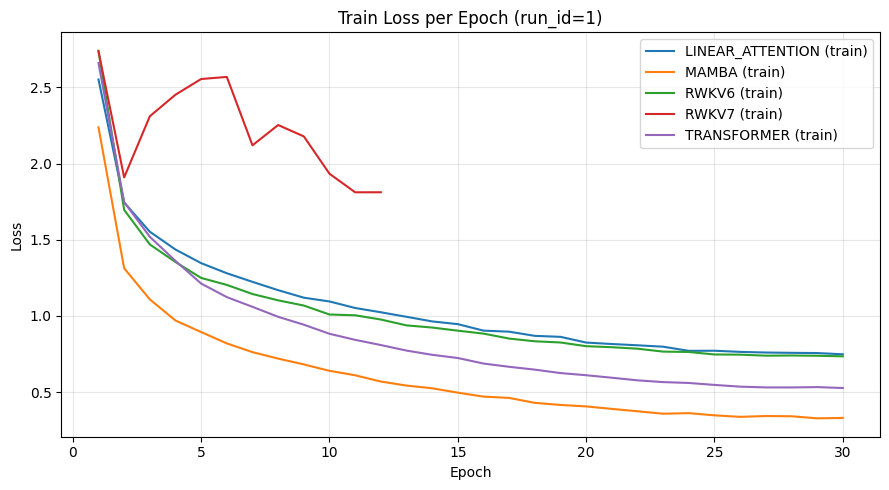

1. On the full utterance ranking Transformer wins outright, Mamba is surprisingly close, RWKV-6 is in the ballpark, Linear Attention is problematic, RWKV-7 is broken and can't converge properly.
2. Carry-state:
  at 2-second chunks, persistent memory recovers 4–5 percentage points of CER. The effect shrinks monotonically as chunk size grows. At 10s, most utterances fit in one chunk so carry is moot.
| | 2s reset → carry | 5s reset → carry | 10s reset → carry |
|---|---|---|---|
| Mamba | 27.0% → 22.2% (**−4.8pp**) | 22.8% → 22.1% (−0.7pp) | 21.8% → 22.0% (+0.2pp) |
| RWKV-6 | 30.8% → 26.4% (**−4.4pp**) | 26.7% → 25.9% (−0.8pp) | 25.9% → 25.9% (≈0) |
3. Reset-state chunking mixes two penalties: limited context and forced forgetting at every chunk boundary, so it obviously the worst for reccurent blocks and Transformer naturally wins even on smaller chunks.
4. But carry-sate seems to have the potential to remove the chunking degradation for Mamba/RWKV. At 2s Mamba: 0.2702 → 0.2224 / RWKV6: 0.3084 → 0.2644. NOTE: carry-state eval runs on the first 500 test utterances while reset-state eval runs on the full test set, so for the fair comparison evaluation on the same subset must be conducted.


Next steps:
1. Fix RWKV7 and potentially RWKV6 too
2. Make carry-state eval comparable
3. Try to impove Linear Attention performance
4. Speed up carry state
5. Longer training (50-80 epochs)
6. LION extention for all reccurent blocks

Potential hyphotesis:
1. Transformer is best offline, but recurrent/SSM models become much more robust under strict chunked inference when evaluated in a realistic streaming mode

#